In [1]:
from astropy.io import fits
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
import pandas as pd

In [2]:
DP = DP()
dps_df, _, left_2comp, right_2comp = DP.extract_fits_data('./catalogs/dp_catalog_test.fits')

In [31]:
delta_dv = dps_df['dv_r'] - dps_df['dv_l']
resolution = c * 0.8 / (Halpha_rest*(1+dps_df['Z']))
sigma_r = np.sqrt(dps_df['sigma_r']**2 + resolution**2)
sigma_l = np.sqrt(dps_df['sigma_l']**2 + resolution**2)
dps_df['delta_dv'] = delta_dv
dps_df['ratio'] = sigma_l / sigma_r

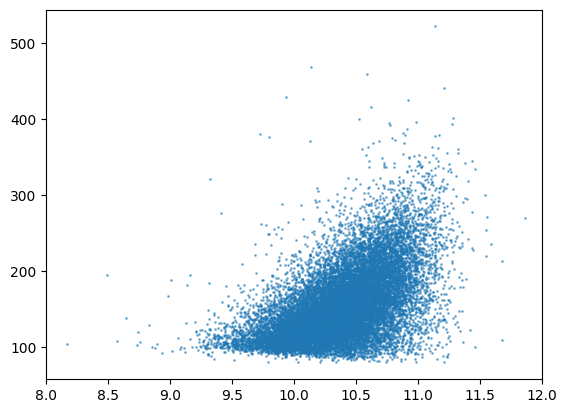

In [51]:
plt.scatter(dps_df['LOGM'], delta_dv, s=1, alpha=0.5)
plt.xlim(left=8, right=12)
plt.show()

In [32]:
dps_1_df = dps_df[(dps_df['delta_dv']<150) & ((dps_df['ratio']<1.5)&(dps_df['ratio']>1/1.5))].copy()
dps_2_df = dps_df[(dps_df['delta_dv']<150) & ((dps_df['ratio']>1.5)|(dps_df['ratio']<1/1.5))].copy()
dps_3_df = dps_df[(dps_df['delta_dv']>150) & ((dps_df['ratio']<1.5)&(dps_df['ratio']>1/1.5))].copy()
dps_4_df = dps_df[(dps_df['delta_dv']>150) & ((dps_df['ratio']>1.5)|(dps_df['ratio']<1/1.5))].copy()
print(len(dps_1_df), len(dps_2_df), len(dps_3_df), len(dps_4_df))

6509 3005 4826 3937


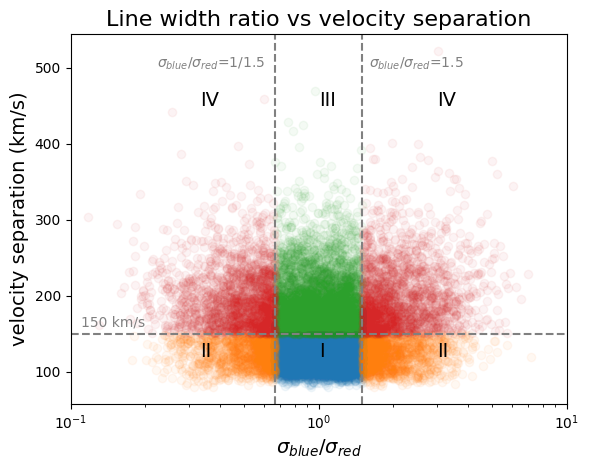

In [40]:
colors = ['C0', 'C1', 'C2', 'C3']
for i, df in enumerate([dps_1_df, dps_2_df, dps_3_df, dps_4_df]):
    plt.scatter(df['ratio'], df['delta_dv'], alpha=.05, color=colors[i])
plt.text(1, 120, 'I', fontsize=14)
plt.text(1/3, 120, 'II', fontsize=14)
plt.text(3, 120, 'II', fontsize=14)
plt.text(1, 450, 'III', fontsize=14)
plt.text(1/3, 450, 'IV', fontsize=14)
plt.text(3, 450, 'IV', fontsize=14)

plt.text(1.6, 500, r'$\sigma_{blue}/\sigma_{red}$=1.5', rotation=0, color='gray', fontsize=10)
plt.axvline(1.5, color='gray', linestyle='--')
plt.text(1/4.5, 500, r'$\sigma_{blue}/\sigma_{red}$=1/1.5', rotation=0, color='gray', fontsize=10)
plt.axvline(1/1.5, color='gray', linestyle='--')
plt.text(0.11, 160, '150 km/s', rotation=0, color='gray', fontsize=10)
plt.axhline(150, color='gray', linestyle='--')
plt.xlabel(r'$\sigma_{blue}/\sigma_{red}$', fontsize=14)
plt.ylabel('velocity separation (km/s)', fontsize=14)
plt.title('Line width ratio vs velocity separation', fontsize=16)
plt.xlim(left=0.1, right=10)
# plt.ylim(bottom=75)
# plt.legend()
plt.xscale('log')
# plt.ylim([0, 500])
plt.savefig('./figures/Jan22/dp_regime.png')
plt.show()

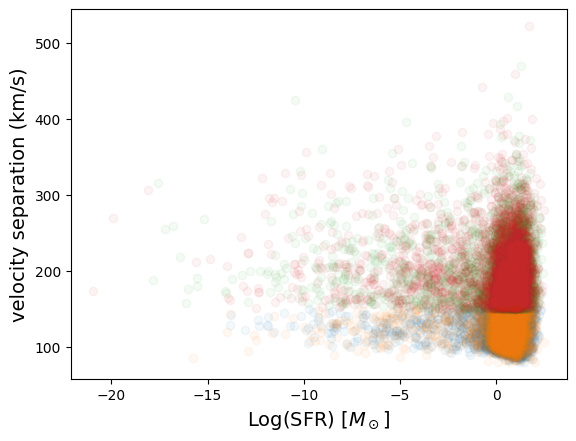

In [55]:
for i, df in enumerate([dps_1_df, dps_2_df, dps_3_df, dps_4_df]):
    plt.scatter(df['LOGSFR'], df['delta_dv'], alpha=.05, color=colors[i])
plt.xlabel(r'Log(SFR) [$M_\odot$]', fontsize=14)
plt.ylabel('velocity separation (km/s)', fontsize=14)
# plt.xlim(left=8, right=12)
plt.show()

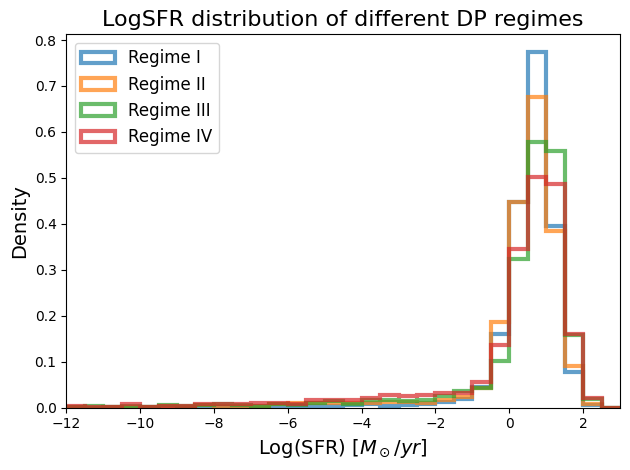

In [ ]:
# plt.hist(dp_samples['LOGSFR'], bins=30, alpha=0.7, label='All Samples', histtype='step', linewidth=3, density=True, cumulative=True, range=(-15, 5))
plt.hist(dps_1_df['LOGSFR'], bins=30, alpha=0.7, label='Regime I', histtype='step', linewidth=3, density=True, cumulative=False, range=(-12, 3))
plt.hist(dps_2_df['LOGSFR'], bins=30, alpha=0.7, label='Regime II', histtype='step', linewidth=3, density=True, cumulative=False, range=(-12, 3))
plt.hist(dps_3_df['LOGSFR'], bins=30, alpha=0.7, label='Regime III', histtype='step', linewidth=3, density=True, cumulative=False, range=(-12, 3))
plt.hist(dps_4_df['LOGSFR'], bins=30, alpha=0.7, label='Regime IV', histtype='step', linewidth=3, density=True, cumulative=False, range=(-12, 3))
plt.xlabel(r'Log(SFR) [$M_\odot/yr$]', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.title('LogSFR distributions of different DP regimes', fontsize=16)
plt.xlim(left=-12, right=3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('./figures/Jan22/dp_regime_logsfr.png')
plt.show()

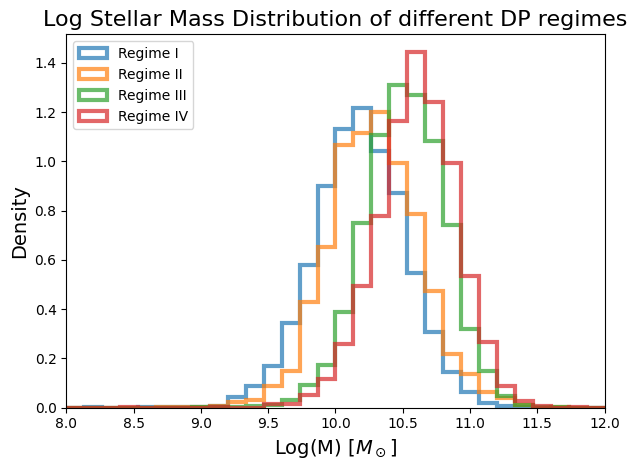

In [48]:
# plt.hist(dp_samples['LOGM'], bins=30, alpha=0.7, label='All Samples', linewidth=3, density=True, range=(8, 12))
plt.hist(dps_1_df['LOGM'], bins=30, alpha=0.7, label='Regime I', histtype='step', linewidth=3, density=True, range=(8, 12), cumulative=False)
plt.hist(dps_2_df['LOGM'], bins=30, alpha=0.7, label='Regime II', histtype='step', linewidth=3, density=True, range=(8, 12), cumulative=False)
plt.hist(dps_3_df['LOGM'], bins=30, alpha=0.7, label='Regime III', histtype='step', linewidth=3, density=True, range=(8, 12), cumulative=False)
plt.hist(dps_4_df['LOGM'], bins=30, alpha=0.7, label='Regime IV', histtype='step', linewidth=3, density=True, range=(8, 12), cumulative=False)
plt.title('Log Stellar Mass Distribution of different DP regimes', fontsize=16)
plt.xlabel(r'Log(M) [$M_\odot$]', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.xlim(left=8, right=12)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('./figures/Jan22/dp_regime_logm.png')
plt.show()

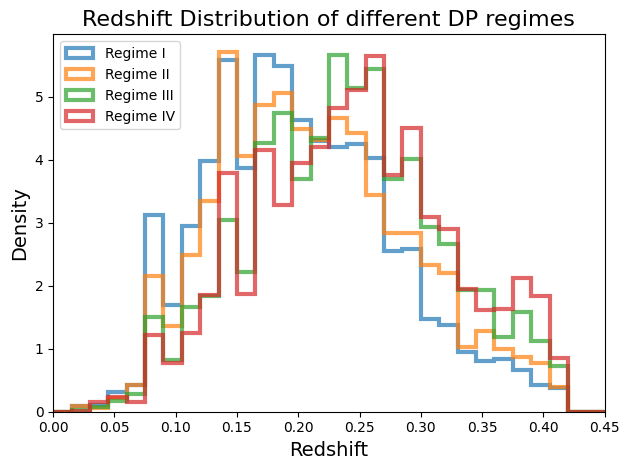

In [49]:
# plt.hist(dp_samples['LOGM'], bins=30, alpha=0.7, label='All Samples', linewidth=3, density=True, range=(8, 12))
plt.hist(dps_1_df['Z'], bins=30, alpha=0.7, label='Regime I', histtype='step', linewidth=3, density=True, range=(0, 0.45), cumulative=False)
plt.hist(dps_2_df['Z'], bins=30, alpha=0.7, label='Regime II', histtype='step', linewidth=3, density=True, range=(0, 0.45), cumulative=False)
plt.hist(dps_3_df['Z'], bins=30, alpha=0.7, label='Regime III', histtype='step', linewidth=3, density=True, range=(0, 0.45), cumulative=False)
plt.hist(dps_4_df['Z'], bins=30, alpha=0.7, label='Regime IV', histtype='step', linewidth=3, density=True, range=(0, 0.45), cumulative=False)
plt.title('Redshift Distribution of different DP regimes', fontsize=16)
plt.xlabel(r'Redshift', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.xlim(left=0, right=0.45)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('./figures/Jan22/dp_regime_z.png')
plt.show()

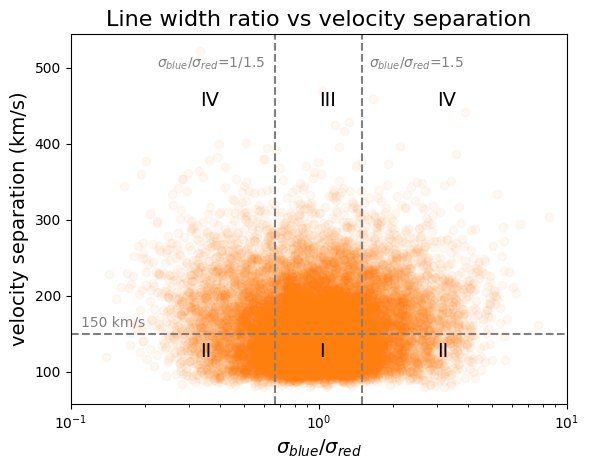

In [34]:
plt.scatter(sigma_r/sigma_l, delta_dv, alpha=.05, color='C1')
plt.text(1, 120, 'I', fontsize=14)
plt.text(1/3, 120, 'II', fontsize=14)
plt.text(3, 120, 'II', fontsize=14)
plt.text(1, 450, 'III', fontsize=14)
plt.text(1/3, 450, 'IV', fontsize=14)
plt.text(3, 450, 'IV', fontsize=14)

plt.text(1.6, 500, r'$\sigma_{blue}/\sigma_{red}$=1.5', rotation=0, color='gray', fontsize=10)
plt.axvline(1.5, color='gray', linestyle='--')
plt.text(1/4.5, 500, r'$\sigma_{blue}/\sigma_{red}$=1/1.5', rotation=0, color='gray', fontsize=10)
plt.axvline(1/1.5, color='gray', linestyle='--')
plt.text(0.11, 160, '150 km/s', rotation=0, color='gray', fontsize=10)
plt.axhline(150, color='gray', linestyle='--')
plt.xlabel(r'$\sigma_{blue}/\sigma_{red}$', fontsize=14)
plt.ylabel('velocity separation (km/s)', fontsize=14)
plt.title('Line width ratio vs velocity separation', fontsize=16)
plt.xlim(left=0.1, right=10)
# plt.ylim(bottom=75)
# plt.legend()
plt.xscale('log')
# plt.ylim([0, 500])
plt.savefig('./figures/Jan22/dp_regime.png')
plt.show()

In [35]:
sf_dps = pd.read_csv('sf_dps.csv')
agn_dps = pd.read_csv('agn_dps.csv')

In [36]:
delta_dv_sf = sf_dps['dv_r'] - sf_dps['dv_l']
resolution = c * 0.8 / (Halpha_rest*(1+sf_dps['Z']))
sigma_r_sf = np.sqrt(sf_dps['sigma_r']**2 + resolution**2)
sigma_l_sf = np.sqrt(sf_dps['sigma_l']**2 + resolution**2)


delta_dv_agn = agn_dps['dv_r'] - agn_dps['dv_l']
resolution = c * 0.8 / (Halpha_rest*(1+agn_dps['Z']))
sigma_r_agn = np.sqrt(agn_dps['sigma_r']**2 + resolution**2)
sigma_l_agn = np.sqrt(agn_dps['sigma_l']**2 + resolution**2)

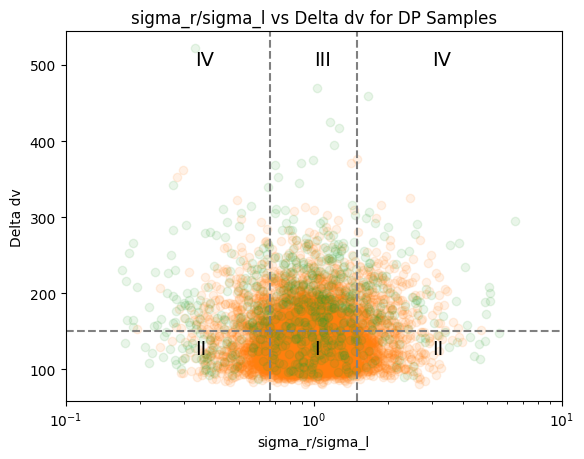

In [37]:
plt.scatter(sigma_r_sf/sigma_l_sf, delta_dv_sf, alpha=.1, color='C1')
plt.scatter(sigma_r_agn/sigma_l_agn, delta_dv_agn, alpha=.1, color='C2')
plt.text(1, 120, 'I', fontsize=14)
plt.text(1/3, 120, 'II', fontsize=14)
plt.text(3, 120, 'II', fontsize=14)
plt.text(1, 500, 'III', fontsize=14)
plt.text(1/3, 500, 'IV', fontsize=14)
plt.text(3, 500, 'IV', fontsize=14)

plt.axvline(1.5, color='gray', linestyle='--')
plt.axvline(1/1.5, color='gray', linestyle='--')
plt.axhline(150, color='gray', linestyle='--')
plt.xlabel('sigma_r/sigma_l')
plt.ylabel('Delta dv')
plt.title('sigma_r/sigma_l vs Delta dv for DP Samples')
plt.xlim(left=0.1, right=10)
# plt.ylim(bottom=75)
# plt.legend()
plt.xscale('log')
# plt.ylim([0, 500])

plt.show()

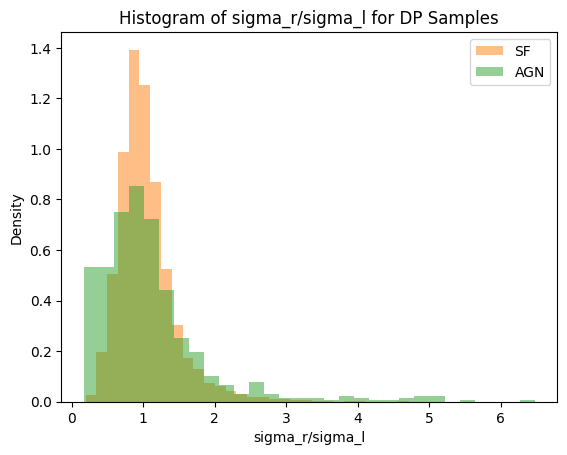

In [38]:
plt.hist(sigma_r_sf/sigma_l_sf, bins=30, alpha=0.5, color='C1', label='SF', density=True)
plt.hist(sigma_r_agn/sigma_l_agn, bins=30, alpha=0.5, color='C2', label='AGN', density=True)
plt.xlabel('sigma_r/sigma_l')
plt.ylabel('Density')
plt.title('Histogram of sigma_r/sigma_l for DP Samples')
plt.legend()
plt.show()

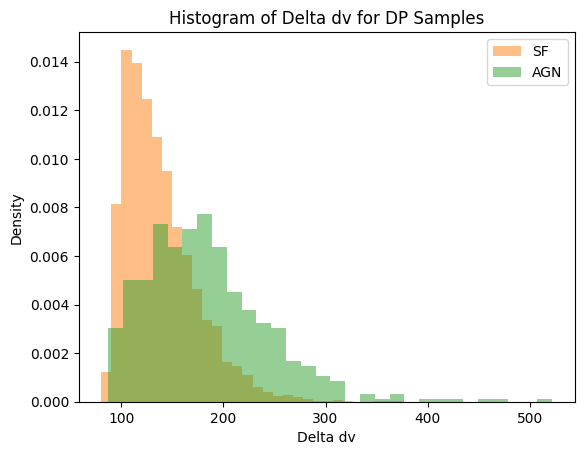

In [39]:
plt.hist(delta_dv_sf, bins=30, alpha=0.5, color='C1', label='SF', density=True)
plt.hist(delta_dv_agn, bins=30, alpha=0.5, color='C2', label='AGN', density=True)
plt.xlabel('Delta dv')
plt.ylabel('Density')
plt.title('Histogram of Delta dv for DP Samples')
plt.legend()
plt.show()